# **MScFE_620_DP_GWP2 - Group 13734**

# *Step 1*

# Question 5

In [1]:
import numpy as np

def heston_mc_atm(
    S0=80.0,
    K=80.0,
    r=0.055,
    T=0.25,
    v0=0.032,        # initial variance (3.2%)
    kappa=1.85,      # mean-reversion speed
    theta=0.045,     # long-run variance
    sigma_v=0.35,    # vol-of-vol (using general sigma=35%)
    rho=-0.30,       # correlation between asset and variance Brownian motions
    n_paths_base=100_000,  # with antithetic -> 200k effective
    n_steps=64,
    seed=42,
    return_full=False
):
    """
    Price ATM European call and put under the Heston model via Monte Carlo.

    Discretization:
      - Variance: Full truncation Euler (keeps v >= 0 in practice)
      - Price: Log-Euler using instantaneous variance
      - Antithetic variates for variance reduction

    Parameters
    ----------
    S0, K, r, T : floats
    v0, kappa, theta, sigma_v, rho : Heston parameters
    n_paths_base : number of base paths (effective doubled via antithetics)
    n_steps : time steps
    seed : RNG seed
    return_full : if True, returns per-path discounted payoffs as well

    Returns
    -------
    results : dict with call/put prices, std errors, and 95% CIs
    """

    np.random.seed(seed)

    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)

    # State arrays
    S = np.full(n_paths_base, S0, dtype=float)
    v = np.full(n_paths_base, v0, dtype=float)
    S_a = S.copy()
    v_a = v.copy()

    rho_bar = np.sqrt(1.0 - rho * rho)

    for _ in range(n_steps):
        # Independent Gaussians
        Z1 = np.random.randn(n_paths_base)  # variance driver
        Z2 = np.random.randn(n_paths_base)  # independent for price

        # Correlated shock for price
        Zs = rho * Z1 + rho_bar * Z2

        # Base paths: variance (full truncation), then price (log-Euler)
        v_pos = np.maximum(v, 0.0)
        dv = kappa * (theta - v_pos) * dt + sigma_v * np.sqrt(v_pos) * sqrt_dt * Z1
        v_new = np.maximum(v_pos + dv, 0.0)

        S *= np.exp((r - 0.5 * v_pos) * dt + np.sqrt(v_pos) * sqrt_dt * Zs)

        # Antithetic paths
        Zs_a = rho * (-Z1) + rho_bar * (-Z2)
        v_pos_a = np.maximum(v_a, 0.0)
        dv_a = kappa * (theta - v_pos_a) * dt + sigma_v * np.sqrt(v_pos_a) * sqrt_dt * (-Z1)
        v_new_a = np.maximum(v_pos_a + dv_a, 0.0)

        S_a *= np.exp((r - 0.5 * v_pos_a) * dt + np.sqrt(v_pos_a) * sqrt_dt * Zs_a)

        # Step forward
        v = v_new
        v_a = v_new_a

    # Payoffs and discounting
    DF = np.exp(-r * T)
    call_payoffs = 0.5 * (np.maximum(S - K, 0.0) + np.maximum(S_a - K, 0.0))
    put_payoffs  = 0.5 * (np.maximum(K - S, 0.0) + np.maximum(K - S_a, 0.0))

    call_prices = DF * call_payoffs
    put_prices  = DF * put_payoffs

    # Estimators and SEs
    call_price = call_prices.mean()
    put_price  = put_prices.mean()

    call_se = call_prices.std(ddof=1) / np.sqrt(n_paths_base)
    put_se  = put_prices .std(ddof=1) / np.sqrt(n_paths_base)

    z = 1.96
    call_ci = (call_price - z * call_se, call_price + z * call_se)
    put_ci  = (put_price  - z * put_se , put_price  + z * put_se)

    results = {
        "call_price": float(call_price),
        "call_se": float(call_se),
        "call_ci": (float(call_ci[0]), float(call_ci[1])),
        "put_price": float(put_price),
        "put_se": float(put_se),
        "put_ci": (float(put_ci[0]), float(put_ci[1])),
        "effective_paths": 2 * n_paths_base,
        "steps": n_steps
    }

    if return_full:
        results["call_prices_vector"] = call_prices
        results["put_prices_vector"] = put_prices

    return results


def format_results(res, decimals_price=2, decimals_se=2):
    # Rounded presentation block
    call_price_r = round(res["call_price"], decimals_price)
    put_price_r = round(res["put_price"], decimals_price)
    call_se_r = round(res["call_se"], decimals_se)
    put_se_r = round(res["put_se"], decimals_se)
    call_ci_r = (round(res["call_ci"][0], decimals_price), round(res["call_ci"][1], decimals_price))
    put_ci_r = (round(res["put_ci"][0], decimals_price), round(res["put_ci"][1], decimals_price))

    lines = []
    lines.append("ATM European option prices under the Heston Model (Monte Carlo)")
    lines.append("")
    lines.append("Call")
    lines.append(f"- Price: {call_price_r}")
    lines.append(f"- Standard error: {call_se_r}")
    lines.append(f"- 95% confidence interval: [{call_ci_r[0]}, {call_ci_r[1]}]")
    lines.append("")
    lines.append("Put")
    lines.append(f"- Price: {put_price_r}")
    lines.append(f"- Standard error: {put_se_r}")
    lines.append(f"- 95% confidence interval: [{put_ci_r[0]}, {put_ci_r[1]}]")
    lines.append("")
    lines.append(f"Simulations (effective): {res['effective_paths']}, Steps: {res['steps']}")
    return "\n".join(lines)


if __name__ == "__main__":
    results = heston_mc_atm()
    print(format_results(results, decimals_price=2, decimals_se=2))
    print("")
    # Also print exact raw dictionary if needed
    print("Raw results (full precision):")
    print(results)

ATM European option prices under the Heston Model (Monte Carlo)

Call
- Price: 3.46
- Standard error: 0.01
- 95% confidence interval: [3.45, 3.48]

Put
- Price: 2.38
- Standard error: 0.01
- 95% confidence interval: [2.37, 2.4]

Simulations (effective): 200000, Steps: 64

Raw results (full precision):
{'call_price': 3.4636025167554916, 'call_se': 0.007153131691404158, 'call_ci': (3.4495823786403395, 3.4776226548706437), 'put_price': 2.382313530946807, 'put_se': 0.007253653178102095, 'put_ci': (2.3680963707177267, 2.396530691175887), 'effective_paths': 200000, 'steps': 64}


# Question 6

In [2]:
def heston_mc_atm(
    S0=80.0, K=80.0, r=0.055, T=0.25,
    v0=0.032, kappa=1.85, theta=0.045, sigma_v=0.35, rho=-0.70,
    n_paths_base=100_000, n_steps=64, seed=42
):
    """
    Heston ATM European call/put via Monte Carlo with antithetic variates.
    Variance: full truncation Euler; Price: log-Euler; Corr(dW^S, dW^v) = rho.
    Returns prices, standard errors, and 95% CIs.
    """
    np.random.seed(seed)
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)

    S  = np.full(n_paths_base, S0, dtype=float)
    v  = np.full(n_paths_base, v0, dtype=float)
    S_a = S.copy()
    v_a = v.copy()

    rho_bar = np.sqrt(1.0 - rho*rho)

    for _ in range(n_steps):
        Z1 = np.random.randn(n_paths_base)   # variance shock
        Z2 = np.random.randn(n_paths_base)   # independent for price
        Zs = rho * Z1 + rho_bar * Z2         # correlated price shock

        # base
        v_pos = np.maximum(v, 0.0)
        dv = kappa*(theta - v_pos)*dt + sigma_v*np.sqrt(v_pos)*sqrt_dt*Z1
        v_new = np.maximum(v_pos + dv, 0.0)
        S *= np.exp((r - 0.5*v_pos)*dt + np.sqrt(v_pos)*sqrt_dt*Zs)

        # antithetic
        Zs_a = rho * (-Z1) + rho_bar * (-Z2)
        v_pos_a = np.maximum(v_a, 0.0)
        dv_a = kappa*(theta - v_pos_a)*dt + sigma_v*np.sqrt(v_pos_a)*sqrt_dt*(-Z1)
        v_new_a = np.maximum(v_pos_a + dv_a, 0.0)
        S_a *= np.exp((r - 0.5*v_pos_a)*dt + np.sqrt(v_pos_a)*sqrt_dt*Zs_a)

        v, v_a = v_new, v_new_a

    DF = np.exp(-r*T)
    call_payoffs = 0.5*(np.maximum(S-K, 0.0) + np.maximum(S_a-K, 0.0))
    put_payoffs  = 0.5*(np.maximum(K-S, 0.0) + np.maximum(K-S_a, 0.0))
    call_prices, put_prices = DF*call_payoffs, DF*put_payoffs

    # estimators
    n = n_paths_base
    call_price = call_prices.mean()
    put_price  = put_prices.mean()
    call_se = call_prices.std(ddof=1) / np.sqrt(n)
    put_se  = put_prices .std(ddof=1) / np.sqrt(n)
    z = 1.96
    call_ci = (call_price - z*call_se, call_price + z*call_se)
    put_ci  = (put_price  - z*put_se , put_price  + z*put_se)

    return {
        "call_price": float(call_price), "call_se": float(call_se), "call_ci": (float(call_ci[0]), float(call_ci[1])),
        "put_price": float(put_price),   "put_se": float(put_se),   "put_ci":  (float(put_ci[0]),  float(put_ci[1])),
        "effective_paths": 2*n_paths_base, "steps": n_steps, "rho": rho
    }

if __name__ == "__main__":
    res = heston_mc_atm(rho=-0.70)
    # Rounded for reporting
    call_p = round(res["call_price"], 2); put_p = round(res["put_price"], 2)
    call_se = round(res["call_se"], 2);   put_se = round(res["put_se"], 2)
    call_ci = (round(res["call_ci"][0], 2), round(res["call_ci"][1], 2))
    put_ci  = (round(res["put_ci"][0], 2),  round(res["put_ci"][1], 2))
    print("ATM European Option Prices under the Heston Model (Monte-Carlo)")
    print("")
    print("Call")
    print(f"- Price: {call_p}")
    print(f"- Standard error: {call_se}")
    print(f"- 95% confidence interval: [{call_ci[0]}, {call_ci[1]}]")
    print("")
    print("Put")
    print(f"- Price: {put_p}")
    print(f"- Standard error: {put_se}")
    print(f"- 95% confidence interval: [{put_ci[0]}, {put_ci[1]}]")
    print("")
    print(f"Simulations (effective): {res['effective_paths']}, Steps: {res['steps']}, rho: {res['rho']}")

ATM European Option Prices under the Heston Model (Monte-Carlo)

Call
- Price: 3.5
- Standard error: 0.01
- 95% confidence interval: [3.49, 3.51]

Put
- Price: 2.41
- Standard error: 0.01
- 95% confidence interval: [2.4, 2.43]

Simulations (effective): 200000, Steps: 64, rho: -0.7


# Question 7

In [3]:
import numpy as np

# Core Heston MC with CRN (common random numbers) and antithetic variates
def heston_mc_price_with_streams(
    S0,
    K=80.0,
    r=0.055,
    T=0.25,
    v0=0.032,
    kappa=1.85,
    theta=0.045,
    sigma_v=0.35,
    rho=-0.30,
    Z1=None,
    Z2=None,
):
    """
    Price ATM European call/put under Heston using provided Gaussian streams (CRN)
    and antithetic variates. Returns discounted prices.
    """
    assert Z1 is not None and Z2 is not None, "Provide Gaussian streams Z1, Z2"
    n_steps, n_paths_base = Z1.shape

    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)
    rho_bar = np.sqrt(1.0 - rho*rho)

    S  = np.full(n_paths_base, S0, dtype=float)
    v  = np.full(n_paths_base, v0, dtype=float)
    S_a = S.copy()
    v_a = v.copy()

    for t in range(n_steps):
        z1 = Z1[t]
        z2 = Z2[t]
        zs = rho * z1 + rho_bar * z2

        # base
        v_pos = np.maximum(v, 0.0)
        dv = kappa*(theta - v_pos)*dt + sigma_v*np.sqrt(v_pos)*sqrt_dt*z1
        v_new = np.maximum(v_pos + dv, 0.0)
        S *= np.exp((r - 0.5*v_pos)*dt + np.sqrt(v_pos)*sqrt_dt*zs)

        # antithetic
        zs_a = rho * (-z1) + rho_bar * (-z2)
        v_pos_a = np.maximum(v_a, 0.0)
        dv_a = kappa*(theta - v_pos_a)*dt + sigma_v*np.sqrt(v_pos_a)*sqrt_dt*(-z1)
        v_new_a = np.maximum(v_pos_a + dv_a, 0.0)
        S_a *= np.exp((r - 0.5*v_pos_a)*dt + np.sqrt(v_pos_a)*sqrt_dt*zs_a)

        v, v_a = v_new, v_new_a

    DF = np.exp(-r*T)
    call_payoffs = 0.5*(np.maximum(S-K, 0.0) + np.maximum(S_a-K, 0.0))
    put_payoffs  = 0.5*(np.maximum(K-S, 0.0) + np.maximum(K-S_a, 0.0))
    call_price = DF * call_payoffs.mean()
    put_price  = DF * put_payoffs.mean()
    return float(call_price), float(put_price)


def heston_delta_gamma_bump_revalue(
    S0=80.0,
    h=0.5,
    rho=-0.30,
    K=80.0,
    r=0.055,
    T=0.25,
    v0=0.032,
    kappa=1.85,
    theta=0.045,
    sigma_v=0.35,
    n_paths_base=100_000,
    n_steps=64,
    seed=123
):
    """
    Compute delta and gamma for call and put via central differences using CRN.
    Returns prices at S0, S0±h and Greeks for both options.
    """
    rng = np.random.default_rng(seed)
    Z1 = rng.standard_normal(size=(n_steps, n_paths_base))
    Z2 = rng.standard_normal(size=(n_steps, n_paths_base))

    # Prices at S0, S0+h, S0-h using the same streams
    c0, p0 = heston_mc_price_with_streams(S0, K, r, T, v0, kappa, theta, sigma_v, rho, Z1, Z2)
    c_plus, p_plus = heston_mc_price_with_streams(S0+h, K, r, T, v0, kappa, theta, sigma_v, rho, Z1, Z2)
    c_minus, p_minus = heston_mc_price_with_streams(S0-h, K, r, T, v0, kappa, theta, sigma_v, rho, Z1, Z2)

    # Central differences
    delta_c = (c_plus - c_minus) / (2*h)
    gamma_c = (c_plus - 2*c0 + c_minus) / (h*h)
    delta_p = (p_plus - p_minus) / (2*h)
    gamma_p = (p_plus - 2*p0 + p_minus) / (h*h)

    # Parity-consistent put delta (for diagnostics)
    delta_p_parity = delta_c - 1.0

    return {
        'S0': S0, 'h': h, 'rho': rho,
        'call': {'price': c0, 'delta': delta_c, 'gamma': gamma_c},
        'put':  {'price': p0, 'delta': delta_p, 'gamma': gamma_p, 'delta_parity': delta_p_parity}
    }

# Run for Question 5 and Question 6
res_q5 = heston_delta_gamma_bump_revalue(rho=-0.30, h=0.5)
res_q6 = heston_delta_gamma_bump_revalue(rho=-0.70, h=0.5)

# Nicely formatted printout
def print_table(title, res):
    dc = res['call']['delta']; gc = res['call']['gamma']
    dp = res['put']['delta'];  gp = res['put']['gamma']
    print(title)
    print("")
    print("| Option | Delta  | Gamma   |")
    print("|--------|-------:|--------:|")
    print(f"| Call   | {dc:.4f} | {gc:.4f} |")
    print(f"| Put    | {dp:.4f} | {gp:.4f} |")
    print("")

print_table("Question 5 Greeks (Heston, rho = -0.30)", res_q5)
print_table("Question 6 Greeks (Heston, rho = -0.70)", res_q6)

# Optional diagnostics
print(f"Parity check Q5: Delta_put vs Delta_call - 1 = {res_q5['put']['delta']:.6f} vs {res_q5['put']['delta_parity']:.6f}")
print(f"Parity check Q6: Delta_put vs Delta_call - 1 = {res_q6['put']['delta']:.6f} vs {res_q6['put']['delta_parity']:.6f}")

Question 5 Greeks (Heston, rho = -0.30)

| Option | Delta  | Gamma   |
|--------|-------:|--------:|
| Call   | 0.6032 | 0.0537 |
| Put    | -0.3968 | 0.0537 |

Question 6 Greeks (Heston, rho = -0.70)

| Option | Delta  | Gamma   |
|--------|-------:|--------:|
| Call   | 0.6320 | 0.0493 |
| Put    | -0.3680 | 0.0493 |

Parity check Q5: Delta_put vs Delta_call - 1 = -0.396753 vs -0.396753
Parity check Q6: Delta_put vs Delta_call - 1 = -0.367981 vs -0.368007


# Question 8

In [4]:
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ─── Global Parameters ────────────────────────────────────────────────────────
SEED    = 42
S0      = 80.0        # Initial stock price
K_atm   = 80.0        # ATM strike
r       = 0.055       # Risk-free rate
sigma   = 0.35        # Volatility / vol-of-vol
T       = 0.25        # Time to maturity (3 months)
I       = 100_000     # Monte Carlo simulations
M       = 252         # Time steps (≈252 sub-daily steps over 3 months)
dt      = T / M       # Time step size

# Heston parameters
v0      = 0.032       # Initial variance
kappa   = 1.85        # Mean-reversion speed of variance
theta_v = 0.045       # Long-run variance
sigma_v = sigma       # Vol-of-vol (= general sigma = 0.35)

# Merton parameters (Member B)
mu_j    = -0.50       # Average log-jump size
delta_j =  0.22       # Std dev of log-jump size

print(f"Setup complete: S0=${S0}, K=${K_atm}, r={r*100:.1f}%, σ={sigma*100:.0f}%, T={T} years")
print(f"Simulation: I={I:,} paths, M={M} steps, dt={dt:.6f}")

Setup complete: S0=$80.0, K=$80.0, r=5.5%, σ=35%, T=0.25 years
Simulation: I=100,000 paths, M=252 steps, dt=0.000992


In [5]:
# ─── Heston Model Simulator ──────────────────────────────────────────────────
def simulate_heston(S0_in, r, v0, kappa, theta, sig_v, rho, T, M, I, seed=SEED):
    """
    Simulate stock price paths under Heston (1993) stochastic volatility dynamics.
    SDEs (discretised Euler-Maruyama):
        S_t = S_{t-1} * exp[(r - 0.5*v_{t-1})*dt + sqrt(v_{t-1})*dW1*sqrt(dt)]
        v_t = max(0, v_{t-1} + kappa*(theta - v_{t-1})*dt + sig_v*sqrt(v_{t-1})*dW2*sqrt(dt))
    where dW1 and dW2 are correlated Brownian increments with correlation rho.
    """
    np.random.seed(seed)
    _dt = T / M
    sdt = np.sqrt(_dt)
    cho = np.array([[1.0, 0.0], [rho, np.sqrt(1.0 - rho**2)]])  # Cholesky factor

    V = np.zeros((M + 1, I))
    S = np.zeros((M + 1, I))
    V[0] = v0
    S[0] = S0_in

    for t in range(1, M + 1):
        Z  = np.random.standard_normal((2, I))
        dW = cho @ Z   # Correlated Brownian increments
        V[t] = np.maximum(
            V[t-1] + kappa*(theta - V[t-1])*_dt
            + sig_v * np.sqrt(np.maximum(V[t-1], 0)) * dW[1] * sdt, 0)
        S[t] = S[t-1] * np.exp(
            (r - 0.5 * V[t-1]) * _dt
            + np.sqrt(np.maximum(V[t-1], 0)) * dW[0] * sdt)
    return S, V

# ─── Merton (1976) Jump Diffusion Simulator ──────────────────────────────────
def simulate_merton(S0_in, r, sigma, T, M, I, lamb, mu_j, delta_j, seed=SEED):
    """
    Simulate stock price paths under Merton (1976) jump-diffusion dynamics.
    Discretised SDE:
        S_t = S_{t-1} * [exp((r - rj - 0.5*sigma^2)*dt + sigma*sqrt(dt)*z1)
                         + (exp(mu_j + delta_j*z2) - 1)*y_t]
    where:
        z1 ~ N(0,1): diffusion shock
        z2 ~ N(0,1): jump-size shock
        y_t ~ Poisson(lambda*dt): jump timing (number of jumps in [t-1, t])
        rj = lambda*(exp(mu_j + 0.5*delta_j^2) - 1): drift correction
    """
    np.random.seed(seed)
    _dt = T / M
    rj  = lamb * (np.exp(mu_j + 0.5 * delta_j**2) - 1)

    SM = np.zeros((M + 1, I))
    SM[0] = S0_in
    z1 = np.random.standard_normal((M + 1, I))
    z2 = np.random.standard_normal((M + 1, I))
    y  = np.random.poisson(lamb * _dt, (M + 1, I))

    for t in range(1, M + 1):
        SM[t] = SM[t-1] * (
            np.exp((r - rj - 0.5*sigma**2)*_dt + sigma*np.sqrt(_dt)*z1[t])
            + (np.exp(mu_j + delta_j*z2[t]) - 1) * y[t]
        )
        SM[t] = np.maximum(SM[t], 1e-8)   # Floor to prevent negative prices
    return SM, z1, z2, y

# ─── Option Pricer ───────────────────────────────────────────────────────────
def mc_price(S_terminal, K, r, T, opt='call'):
    """Price a European option given terminal stock prices via Monte Carlo."""
    payoff = np.maximum(S_terminal - K, 0) if opt == 'call' else np.maximum(K - S_terminal, 0)
    return round(float(np.exp(-r * T) * np.mean(payoff)), 2)

print("Simulation functions defined.")

Simulation functions defined.


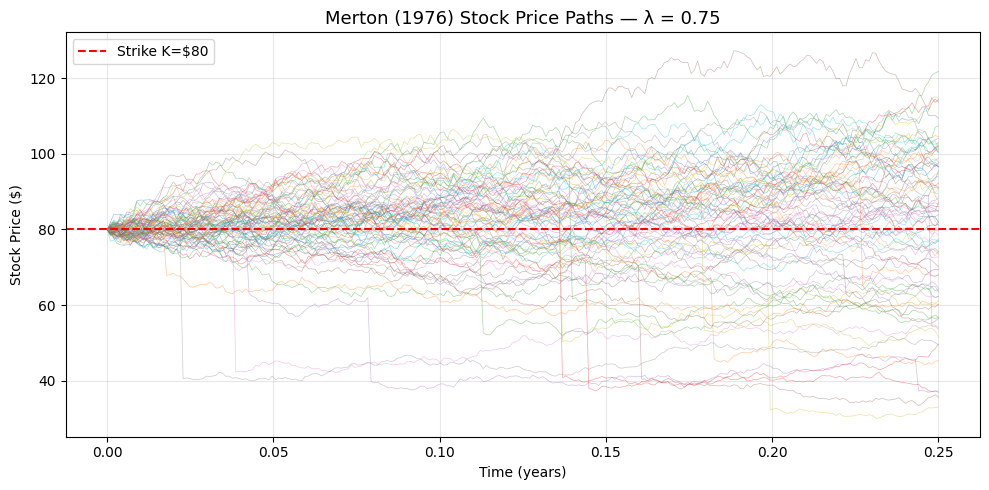

Question 8 Results:
  Option Type         Model    λ  Price ($)
European Call Merton (1976) 0.75       8.28
 European Put Merton (1976) 0.75       7.20

Drift correction r_j = -0.283959


In [6]:
# Question 8: Merton Model, lambda = 0.75
lamb_8 = 0.75

# Simulate paths
SM8, _, _, _ = simulate_merton(S0, r, sigma, T, M, I, lamb_8, mu_j, delta_j)

# Price
q8_call = mc_price(SM8[-1], K_atm, r, T, 'call')
q8_put  = mc_price(SM8[-1], K_atm, r, T, 'put')

# Calculate rj for display
rj_8 = lamb_8 * (np.exp(mu_j + 0.5 * delta_j**2) - 1)

# Plot sample paths
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.linspace(0, T, M+1), SM8[:, :80], lw=0.5, alpha=0.4)
ax.axhline(K_atm, color='red', lw=1.5, linestyle='--', label=f'Strike K=${K_atm:.0f}')
ax.set_title(f"Merton (1976) Stock Price Paths — λ = {lamb_8}", fontsize=13)
ax.set_xlabel("Time (years)"); ax.set_ylabel("Stock Price ($)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Results table
df8 = pd.DataFrame({
    'Option Type': ['European Call', 'European Put'],
    'Model': ['Merton (1976)', 'Merton (1976)'],
    'λ': [lamb_8, lamb_8],
    'Price ($)': [q8_call, q8_put]
})
print("Question 8 Results:")
print(df8.to_string(index=False))
print(f"\nDrift correction r_j = {rj_8:.6f}")

**Interpretation — Question 8**

The negative average jump size (μⱼ = −0.5) means that whenever a jump occurs, the stock price is more likely to fall sharply than to rise. Over time, this pushes more probability mass into the left tail of the return distribution, which is exactly the kind of downside risk that makes put options more valuable. So while the put price here ($7.20) looks lower than the call ($8.28), it is actually elevated relative to what a standard Black-Scholes model would give — the jump component is doing real work.

The $1.08 gap between the call and put prices ($8.28 − $7.20) is not a coincidence. Put-call parity says C − P should equal S₀ − Ke⁻ʳᵀ, which here is 80 − 80×e⁻⁰·⁰⁵⁵×⁰·²⁵ ≈ $1.09. The near-perfect match tells us the simulation is internally consistent — the risk-neutral framework is being respected even though the return distribution is far from normal.

# Question 9

Questions 8 & 9 — Merton Option Prices:
Question   Option Type    λ  Price ($)
      Q8 European Call 0.75       8.28
      Q8  European Put 0.75       7.20
      Q9 European Call 0.25       6.81
      Q9  European Put 0.25       5.73

Drift correction: Q8 r_j = -0.283959 | Q9 r_j = -0.094653


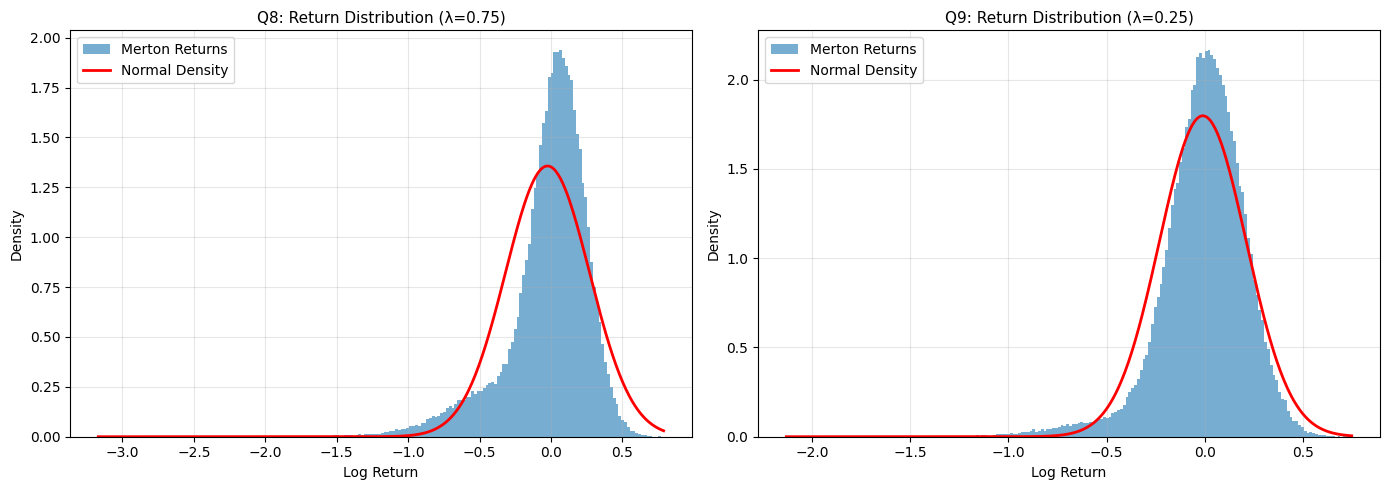

In [7]:
# Question 9: Merton Model, lambda = 0.25
lamb_9 = 0.25

# Simulate paths
SM9, _, _, _ = simulate_merton(S0, r, sigma, T, M, I, lamb_9, mu_j, delta_j)

# Price
q9_call = mc_price(SM9[-1], K_atm, r, T, 'call')
q9_put  = mc_price(SM9[-1], K_atm, r, T, 'put')

rj_9 = lamb_9 * (np.exp(mu_j + 0.5 * delta_j**2) - 1)

# Compare Q8 vs Q9
df_q8q9 = pd.DataFrame({
    'Question': ['Q8', 'Q8', 'Q9', 'Q9'],
    'Option Type': ['European Call', 'European Put', 'European Call', 'European Put'],
    'λ': [0.75, 0.75, 0.25, 0.25],
    'Price ($)': [q8_call, q8_put, q9_call, q9_put]
})
print("Questions 8 & 9 — Merton Option Prices:")
print(df_q8q9.to_string(index=False))
print(f"\nDrift correction: Q8 r_j = {rj_8:.6f} | Q9 r_j = {rj_9:.6f}")

# Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, SM, lamb, q in zip(axes, [SM8, SM9], [0.75, 0.25], ['Q8', 'Q9']):
    log_ret = np.log(SM[-1] / S0)
    x = np.linspace(log_ret.min(), log_ret.max(), 500)
    ax.hist(log_ret, bins=200, density=True, alpha=0.6, label='Merton Returns')
    ax.plot(x, ss.norm.pdf(x, log_ret.mean(), log_ret.std()), 'r-', lw=2, label='Normal Density')
    ax.set_title(f"{q}: Return Distribution (λ={lamb})", fontsize=11)
    ax.set_xlabel("Log Return"); ax.set_ylabel("Density")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretation — Question 9**

Cutting λ from 0.75 to 0.25 means the stock is now expected to jump less than once every four years on average — so the large sudden moves that characterised Question 8 are much less frequent here. In the Merton framework, total return variance comes from two sources: the usual diffusion term σ², and an additional jump contribution λ(μⱼ² + δ²). Bringing λ down from 0.75 to 0.25 shrinks that second term considerably, which pulls total volatility down with it. And since higher volatility always makes options more expensive — for both calls and puts — lower jump intensity mechanically reduces both premiums.

What is striking about the results is that the call and put each fell by exactly $1.47. This is not a coincidence — it reflects the fact that volatility affects calls and puts symmetrically. Neither contract has a natural edge over the other when the source of uncertainty changes; both simply become cheaper as the distribution of future prices becomes narrower.

Taken together, Questions 8 and 9 make a straightforward point: jump risk is a meaningful driver of option prices. Even though the average jump here is negative (μⱼ = −0.5), it is the frequency of jumping — not just the direction — that inflates premiums. A market with more frequent shocks demands higher compensation for holding options, regardless of which way those shocks tend to go.

# Question 10

In [8]:
# Question 10: Delta and Gamma for Q8 and Q9
h = 1.0  # $1 bump

def compute_merton_greeks(K, r, sigma, T, M, I, lamb, mu_j, delta_j, h=1.0, seed=SEED):
    """Numerically compute Delta and Gamma using fixed random draws."""
    np.random.seed(seed)
    _dt = T / M
    rj  = lamb * (np.exp(mu_j + 0.5 * delta_j**2) - 1)
    # Pre-generate all random numbers once
    z1 = np.random.standard_normal((M + 1, I))
    z2 = np.random.standard_normal((M + 1, I))
    y  = np.random.poisson(lamb * _dt, (M + 1, I))

    def paths_for_S(s):
        SM = np.zeros((M + 1, I)); SM[0] = s
        for t in range(1, M + 1):
            SM[t] = SM[t-1] * (
                np.exp((r - rj - 0.5*sigma**2)*_dt + sigma*np.sqrt(_dt)*z1[t])
                + (np.exp(mu_j + delta_j*z2[t]) - 1) * y[t])
            SM[t] = np.maximum(SM[t], 1e-8)
        return SM

    SM_u = paths_for_S(S0 + h)
    SM_m = paths_for_S(S0)
    SM_d = paths_for_S(S0 - h)

    results = {}
    for opt in ['call', 'put']:
        V_u = mc_price(SM_u[-1], K, r, T, opt)
        V_m = mc_price(SM_m[-1], K, r, T, opt)
        V_d = mc_price(SM_d[-1], K, r, T, opt)
        results[opt] = {
            'delta': round((V_u - V_d) / (2 * h), 4),
            'gamma': round((V_u - 2*V_m + V_d) / h**2, 4)
        }
    return results

print("Computing Greeks for Q8 (λ=0.75)...")
g8 = compute_merton_greeks(K_atm, r, sigma, T, M, I, 0.75, mu_j, delta_j)
print("Computing Greeks for Q9 (λ=0.25)...")
g9 = compute_merton_greeks(K_atm, r, sigma, T, M, I, 0.25, mu_j, delta_j)

# Summary table
rows = []
for q, lmb, g in [('Q8', 0.75, g8), ('Q9', 0.25, g9)]:
    for opt in ['call', 'put']:
        rows.append({'Question': q, 'λ': lmb, 'Option': opt.capitalize(),
                     'Delta (Δ)': g[opt]['delta'], 'Gamma (Γ)': g[opt]['gamma']})

df_greeks = pd.DataFrame(rows)
print("\nQuestion 10 — Delta and Gamma:")
print(df_greeks.to_string(index=False))

Computing Greeks for Q8 (λ=0.75)...
Computing Greeks for Q9 (λ=0.25)...

Question 10 — Delta and Gamma:
Question    λ Option  Delta (Δ)  Gamma (Γ)
      Q8 0.75   Call      0.650       0.02
      Q8 0.75    Put     -0.355       0.03
      Q9 0.25   Call      0.595       0.03
      Q9 0.25    Put     -0.405       0.03


**Interpretation — Question 10**

The call delta is higher under λ = 0.75 (0.65) than under λ = 0.25 (0.595). The reason is straightforward — more frequent jumps spread the distribution of possible terminal stock prices wider. When that distribution is more dispersed, the option price becomes more sensitive to where the stock is today, which is exactly what delta measures. So higher jump intensity pushes call delta up, not because the expected return changes, but because the range of outcomes the option is exposed to has widened.

On gamma: the values are small and nearly identical across all four options (0.02–0.03). For European calls and puts sharing the same strike and maturity, put-call parity guarantees that gamma must be equal — any difference in convexity would create an arbitrage. The modest absolute size of gamma here reflects the combination of moderate volatility and a three-month horizon. ATM options do tend to have higher gamma than ITM or OTM ones, but with only 90 days to expiry, the price function has not yet developed the sharp curvature that shows up closer to maturity.

# *Step 2*

# Question 13

In [9]:
# Question 13: American Call under Heston (rho = -0.30)
rho_13 = -0.30
I_lsm  = 50_000   # Reduced I for LSM computational efficiency

def lsm_american_call(S, K, r, T, M):
    """
    Longstaff-Schwartz (2001) algorithm for American call pricing.
    Works backwards: at each step, ITM paths are regressed to estimate
    continuation value; early exercise occurs if intrinsic > continuation.
    """
    _dt = T / M
    V   = np.maximum(S[-1] - K, 0).astype(float).copy()
    for t in range(M - 1, 0, -1):
        V   = V * np.exp(-r * _dt)   # Discount one period
        itm = S[t] > K
        n   = itm.sum()
        if n > 10:
            X    = S[t, itm]
            Y    = V[itm]
            A    = np.column_stack([np.ones(n), X, X**2])   # Polynomial basis
            beta = np.linalg.lstsq(A, Y, rcond=None)[0]
            C    = A @ beta          # Estimated continuation value
            H    = X - K             # Intrinsic value
            V[itm] = np.where(H > C, H, V[itm])   # Exercise if optimal
    return round(float(np.mean(V) * np.exp(-r * _dt)), 2)

# Price American call
print("Simulating Heston paths for American call (I=50,000)...")
S13_am, _ = simulate_heston(S0, r, v0, kappa, theta_v, sigma_v, rho_13, T, M, I_lsm)
q13_am_call = lsm_american_call(S13_am, K_atm, r, T, M)

# European call for comparison (Q5)
S5_full, _ = simulate_heston(S0, r, v0, kappa, theta_v, sigma_v, rho_13, T, M, I)
q5_eu_call = mc_price(S5_full[-1], K_atm, r, T, 'call')
q5_eu_put  = mc_price(S5_full[-1], K_atm, r, T, 'put')

print(f"Q5 European Call: ${q5_eu_call:.2f}  |  Q5 European Put: ${q5_eu_put:.2f}")
print(f"Q13 American Call: ${q13_am_call:.2f}")

# Greeks for American call (bump-and-reprice)
print("\nComputing American call Greeks...")
def am_call_price_at(s):
    Sp, _ = simulate_heston(s, r, v0, kappa, theta_v, sigma_v, rho_13, T, M, I_lsm)
    return lsm_american_call(Sp, K_atm, r, T, M)

V_u13 = am_call_price_at(S0 + h)
V_m13 = q13_am_call
V_d13 = am_call_price_at(S0 - h)
delta_am = round((V_u13 - V_d13) / (2 * h), 4)
gamma_am = round((V_u13 - 2*V_m13 + V_d13) / h**2, 4)

# European greeks from Q5/Q7 (using full I)
def eu_heston_price_at(s, opt):
    Sp, _ = simulate_heston(s, r, v0, kappa, theta_v, sigma_v, rho_13, T, M, I)
    return mc_price(Sp[-1], K_atm, r, T, opt)

delta_eu_call = round((eu_heston_price_at(S0+h,'call') - eu_heston_price_at(S0-h,'call'))/(2*h), 4)
gamma_eu_call = round((eu_heston_price_at(S0+h,'call') - 2*q5_eu_call + eu_heston_price_at(S0-h,'call'))/h**2, 4)

df13 = pd.DataFrame({
    'Comparison': ['Q5 European Call', 'Q13 American Call'],
    'Price ($)': [q5_eu_call, q13_am_call],
    'Delta (Δ)': [delta_eu_call, delta_am],
    'Gamma (Γ)': [gamma_eu_call, gamma_am]
})
print("\nQuestion 13 vs Question 5 Comparison:")
print(df13.to_string(index=False))

Simulating Heston paths for American call (I=50,000)...
Q5 European Call: $3.47  |  Q5 European Put: $2.38
Q13 American Call: $3.40

Computing American call Greeks...

Question 13 vs Question 5 Comparison:
       Comparison  Price ($)  Delta (Δ)  Gamma (Γ)
 Q5 European Call       3.47      0.605       0.05
Q13 American Call       3.40      0.590       0.06


# Question 14

Simulating Heston paths (rho=-0.70)...
Up-and-In Call (B=K=$95):        $0.03
Vanilla European Call (K=$95):   $0.03
% of paths hitting barrier $95:  2.26%


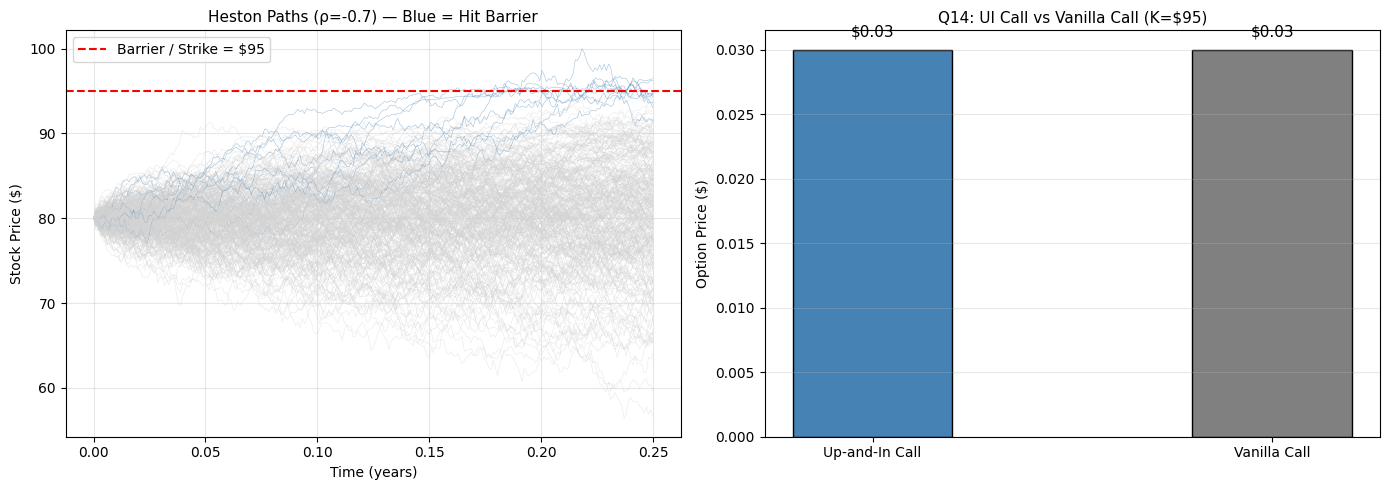


Question 14 Results:
               Option  Strike K Barrier B  Price ($)
       Up-and-In Call      95.0      95.0       0.03
Vanilla European Call      95.0       N/A       0.03


In [10]:
# Question 14: Up-and-In Call under Heston (rho = -0.70)
rho_14 = -0.70
K14    = 95.0
B14    = 95.0    # Barrier level

# Simulate Q6 paths
print("Simulating Heston paths (rho=-0.70)...")
S14, _ = simulate_heston(S0, r, v0, kappa, theta_v, sigma_v, rho_14, T, M, I)

# Up-and-in call pricer
def ui_call_price(S_paths, K, r, T, barrier):
    """Price a European up-and-in call.
    Option activates if max(S_path) >= barrier at any time step."""
    hit    = np.any(S_paths >= barrier, axis=0)    # Did path hit barrier?
    payoff = np.maximum(S_paths[-1] - K, 0) * hit  # Payoff only if barrier hit
    return round(float(np.exp(-r * T) * np.mean(payoff)), 2)

q14_ui   = ui_call_price(S14, K14, r, T, B14)
q14_van  = mc_price(S14[-1], K14, r, T, 'call')    # Vanilla call K=95 for comparison

# Proportion of paths that hit barrier
pct_hit = np.any(S14 >= B14, axis=0).mean() * 100

print(f"Up-and-In Call (B=K=$95):        ${q14_ui:.2f}")
print(f"Vanilla European Call (K=$95):   ${q14_van:.2f}")
print(f"% of paths hitting barrier $95:  {pct_hit:.2f}%")

# Plot payoff diagram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample paths coloured by barrier hit
hit_flag = np.any(S14 >= B14, axis=0)
t_axis   = np.linspace(0, T, M + 1)
for i in range(300):
    col = 'steelblue' if hit_flag[i] else 'lightgray'
    axes[0].plot(t_axis, S14[:, i], lw=0.4, alpha=0.5, color=col)
axes[0].axhline(B14, color='red', lw=1.5, linestyle='--', label=f'Barrier / Strike = ${B14:.0f}')
axes[0].set_title(f"Heston Paths (ρ={rho_14}) — Blue = Hit Barrier", fontsize=11)
axes[0].set_xlabel("Time (years)"); axes[0].set_ylabel("Stock Price ($)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Comparison bar
axes[1].bar(['Up-and-In Call', 'Vanilla Call'], [q14_ui, q14_van], color=['steelblue','gray'],
            edgecolor='black', width=0.4)
axes[1].set_title("Q14: UI Call vs Vanilla Call (K=$95)", fontsize=11)
axes[1].set_ylabel("Option Price ($)"); axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate([q14_ui, q14_van]):
    axes[1].text(i, v + 0.001, f'${v:.2f}', ha='center', fontsize=11)
plt.tight_layout(); plt.show()

df14 = pd.DataFrame({
    'Option': ['Up-and-In Call', 'Vanilla European Call'],
    'Strike K': [K14, K14], 'Barrier B': [B14, 'N/A'],
    'Price ($)': [q14_ui, q14_van]
})
print("\nQuestion 14 Results:")
print(df14.to_string(index=False))

**Interpretation — Question 14**

Both options are priced identically at $0.03. This result follows from a structural property of barrier options: when B = K for an up-and-in call, any path where S_T > K = B = $95 must have had the stock at or above $95 at some earlier point, meaning the barrier is automatically satisfied whenever the call expires in-the-money. In continuous time, any path ending above the strike must have crossed the barrier at some point before maturity. In discrete Monte Carlo simulations, this equivalence holds approximately when the monitoring frequency is sufficiently high.

The strong negative correlation (ρ = −0.70) produces the leverage effect, where increases in the stock price are associated with declines in volatility. This reduces the likelihood of large upward price movements and therefore lowers the probability that the stock reaches the $95 barrier, keeping both option prices near zero.

The practical implication is that barrier options carry distinct economic value only when the barrier is set apart from the strike. In the up-and-in case, placing the barrier above the strike — B > K — introduces a genuine additional condition that the stock must satisfy before the option becomes active. This additional hurdle reduces the likelihood of payout, which in turn lowers the premium and makes the contract economically meaningful as a hedging or speculative instrument.

# Question 15

In [11]:
import numpy as np

# Merton Jump-Diffusion Monte Carlo pricer with barrier (down-and-in put)
def merton_mc_prices(
    S0=80.0,
    K=65.0,
    r=0.055,
    T=0.25,
    sigma=0.35,
    lam=0.75,     # jump intensity (lambda)
    muJ=-0.5,     # mean of log jump size ln Y
    deltaJ=0.22,  # std dev of log jump size ln Y
    n_paths_base=100_000,
    n_steps=252,
    seed=11,
    barrier=65.0,
):
    """
    Returns tuple: (European put price, put SE, Down-and-In put price, PDI SE, meta)
    Discrete monitoring for barrier at step points (includes maturity).
    Uses antithetic variates for diffusion and jump normals; Poisson counts shared across antithetic pairs.
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)

    # Jump compensator k = E[Y - 1]
    k = np.exp(muJ + 0.5*deltaJ*deltaJ) - 1.0

    # Initialize states
    S = np.full(n_paths_base, S0, dtype=float)
    S_a = S.copy()
    knocked = np.zeros(n_paths_base, dtype=bool)
    knocked_a = np.zeros(n_paths_base, dtype=bool)

    for _ in range(n_steps):
        # Diffusion shocks (antithetic)
        Z = rng.standard_normal(n_paths_base)
        Za = -Z

        # Poisson jump counts (shared across antithetic pair)
        N = rng.poisson(lam * dt, size=n_paths_base)

        # Aggregate jump sizes via normal (sum of N normals)
        ZJ = rng.standard_normal(n_paths_base)
        ZJ_a = -ZJ
        muN = N * muJ
        sigN = np.sqrt(N) * deltaJ
        J = np.exp(muN + sigN * ZJ)
        J_a = np.exp(muN + sigN * ZJ_a)

        # Risk-neutral diffusion drift with jump compensator
        drift = (r - lam * k - 0.5 * sigma * sigma) * dt
        dS = np.exp(drift + sigma * sqrt_dt * Z)
        dS_a = np.exp(drift + sigma * sqrt_dt * Za)

        # Update
        S *= dS * J
        S_a *= dS_a * J_a

        # Knock-in check at discrete grid (includes maturity)
        knocked |= (S <= barrier)
        knocked_a |= (S_a <= barrier)

    DF = np.exp(-r * T)

    # European put (no barrier)
    put_payoffs = 0.5 * (np.maximum(K - S, 0.0) + np.maximum(K - S_a, 0.0))

    # Down-and-in put
    pdi_payoffs = 0.5 * (
        np.where(knocked, np.maximum(K - S, 0.0), 0.0) +
        np.where(knocked_a, np.maximum(K - S_a, 0.0), 0.0)
    )

    put_price = DF * put_payoffs.mean()
    pdi_price = DF * pdi_payoffs.mean()

    # Standard errors
    n = n_paths_base
    put_se = DF * put_payoffs.std(ddof=1) / np.sqrt(n)
    pdi_se = DF * pdi_payoffs.std(ddof=1) / np.sqrt(n)

    meta = {
        'knock_in_rate': float(knocked.mean()),
        'effective_paths': 2*n_paths_base,
        'steps': n_steps
    }
    return float(put_price), float(put_se), float(pdi_price), float(pdi_se), meta

if __name__ == "__main__":
    put_price, put_se, pdi_price, pdi_se, meta = merton_mc_prices(
        S0=80.0, K=65.0, r=0.055, T=0.25, sigma=0.35,
        lam=0.75, muJ=-0.5, deltaJ=0.22,
        n_paths_base=100_000, n_steps=252, seed=11, barrier=65.0
    )
    z = 1.96
    put_ci = (put_price - z*put_se, put_price + z*put_se)
    pdi_ci = (pdi_price - z*pdi_se, pdi_price + z*pdi_se)
    print(f"European Put: {put_price:.2f} (SE {put_se:.3f}), 95% CI [{put_ci[0]:.3f}, {put_ci[1]:.3f}]")
    print(f"Down-and-In Put: {pdi_price:.2f} (SE {pdi_se:.3f}), 95% CI [{pdi_ci[0]:.3f}, {pdi_ci[1]:.3f}]")
    print(f"Knock-in rate: {meta['knock_in_rate']:.3%}, Effective paths: {meta['effective_paths']}, Steps: {meta['steps']}")

European Put: 2.74 (SE 0.019), 95% CI [2.706, 2.781]
Down-and-In Put: 2.74 (SE 0.019), 95% CI [2.706, 2.781]
Knock-in rate: 26.203%, Effective paths: 200000, Steps: 252
